# Set-Up

In [1]:
import numpy as np
from scipy.optimize import curve_fit
from astropy import constants as const, units as u
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [2]:
import sys
sys.path.append('../')
from functions import epsilon, Mchirp

In [3]:
# Simulation constants

M1     = 0.335*const.M_sun.value          # White dwarf mass 1
M2     = 0.323*const.M_sun.value          # White dwarf mass 2
Mchirp = Mchirp(M1, M2) * u.kg.to(u.Msun) # Binary chirp mass

Msys = M1 + M2                   # Binary system mass
fgw0 = 3.79e-3                   # Initial GW frequency
inc  = np.pi/2                   # Exoplanet inclination

# Equation 5 power law relationship

Run the `lisasim_snr.py` script to generate the data for this power law test.

In [4]:
data = np.loadtxt("../LISAsim_data_files/snrdiff.txt")

# The exoplanet distance and observation time used in the simulation
D      = 150  # units: pc
Tobs   = 10   # units: year

# Calculate modulation index values
ep = epsilon(data[:,1], inc, 1/data[:,0], fgw0, Msys)

# Convert units
data[:,0] = data[:,0]*u.s.to(u.year)
data[:,1] = data[:,1]*u.kg.to(const.M_jup)

df = pd.DataFrame(data    = np.hstack((data,ep[:,np.newaxis])),
                  columns = ['P', 'M', 'SNRres', 'ep'],
                  )
df

,P,M,SNRres,ep
0,0.002738,0.100000,0.075763,0.000029
1,0.002738,0.125128,0.094798,0.000037
2,0.002738,0.156569,0.118615,0.000046
3,0.002738,0.195911,0.148414,0.000057
4,0.002738,0.245139,0.185698,0.000072
...,...,...,...,...
1439,10.000000,163.172926,6176.575713,9.856429
1440,10.000000,204.174299,5799.756163,11.952853
1441,10.000000,255.478317,4916.909148,14.409844
1442,10.000000,319.673782,5058.855944,17.257540


In [5]:
df_condition = df[df.SNRres < 1000]

print("Max epsilon under condition =", df_condition['ep'].max())

df_condition = df_condition.to_numpy()

print("Number of data points that satisfy the condition: ", df_condition.shape[0])

Max epsilon under condition = 0.3911704745538787
Number of data points that satisfy the condition:  1155


Let's test the following power law functional form:

$
\Big(\frac{P}{\text{1 year}}\Big) = a \Big(\frac{\text{SNR}_\text{res}}{5}\Big)^b \Big(\frac{M}{\text{M}_\text{Jup}}\Big)^c \Big(\frac{\text{M}_\odot}{\text{M}_\text{sys} + M}\Big)^d
$

We will check both a "linear" and "log" fit of this equation to the data.

In [6]:
def Pfunc(X, a, b, c, d):
    M, SNRres = X
    return a * (SNRres/5)**b * (M/1)**c * (1 / ((Msys*u.kg.to(u.Msun)) + (M*u.Mjup.to(u.Msun))))**d

Xdata = df_condition[:,[1,2]].T
Ydata = df_condition[:,0]

popt, pcov = curve_fit(Pfunc, Xdata, Ydata, p0=[1,3/2,-3/2,-1])

print("Best fit values (linear-fit): ", popt)

Best fit values (linear-fit):  [ 0.08320174  1.50172376 -1.50164398 -1.40609678]


In [7]:
def log10Pfunc(X, a, b, c, d):
    M, SNRres = X
    return np.log10(a) + b*np.log10(SNRres/5) + c*np.log10(M/1) + d*np.log10((1 / ((Msys*u.kg.to(u.Msun)) + (M*u.Mjup.to(u.Msun)))))

Xdata = df_condition[:,[1,2]].T
Ydata = df_condition[:,0]

popt, pcov = curve_fit(log10Pfunc, Xdata, np.log10(Ydata), p0=[1,3/2,-3/2,-1])

print("Best fit values (log-fit): ", popt)

Best fit values (log-fit):  [ 0.07067708  1.50090974 -1.50069799 -1.00368236]


/var/folders/66/47rx8tnd05173x195n9trmvr0000gp/T/ipykernel_30137/3149292554.py:3: RuntimeWarning: invalid value encountered in log10
  return np.log10(a) + b*np.log10(SNRres/5) + c*np.log10(M/1) + d*np.log10((1 / ((Msys*u.kg.to(u.Msun)) + (M*u.Mjup.to(u.Msun)))))


# Distance power law

Run the `lisasim_snr_dist.py` script to generate the data for this power law test.

In [8]:
data = np.loadtxt("../LISAsim_data_files/snrdiff_dist.txt")

# Convert units
data[:,0] = data[:,0]*u.m.to(u.pc)

df = pd.DataFrame(data    = data,
                  columns = ['R', 'SNRres'],
                  )
df

,R,SNRres
0,50.000000,173.985794
1,72.961640,119.231005
2,106.468019,81.708008
3,155.361625,55.993812
4,226.708780,38.372090
5,330.820888,26.296071
6,482.744692,18.020477
7,704.436890,12.349282
8,1027.937418,8.462859
9,1500.000000,5.799526


In [9]:
df_condition = df#[df.SNRres < 100]

df_condition = df_condition.to_numpy()

print("Number of data points that satisfy the condition: ", df_condition.shape[0])

Number of data points that satisfy the condition:  10


Let's test the following power law functional form:

$
\text{SNR}_\text{res} = a \Big(\frac{D}{150\text{pc}}\Big)^b
$

In [10]:
def SNRfunc(D, a, b):
    return a * (D/150)**b

Xdata = df_condition[:,0]
Ydata = df_condition[:,1]

popt, pcov = curve_fit(SNRfunc, Xdata, Ydata)#, p0=[1,1,-2/3])

print("Best fit values: ", popt)

Best fit values:  [57.99526472 -1.        ]


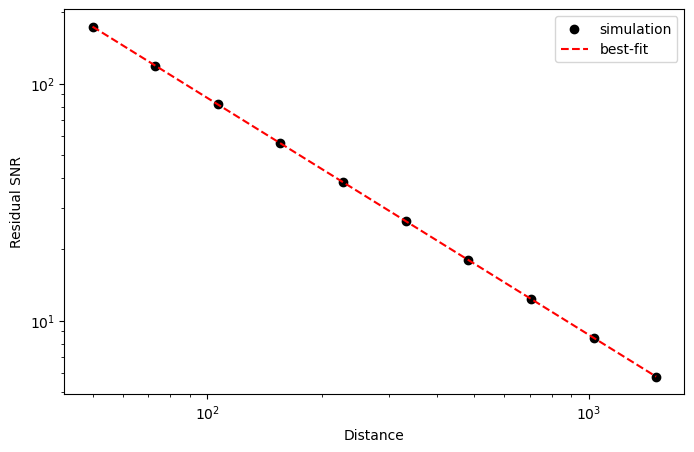

In [11]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
ax.set_xscale('log'), ax.set_yscale('log')

Rvals = np.logspace(np.log10(df['R'].min()), np.log10(df['R'].max()))

ax.scatter(Xdata, Ydata, label='simulation', color='k')
ax.plot(Rvals, SNRfunc(Rvals, *popt), label='best-fit', color='r', linestyle='--')

ax.set_xlabel('Distance'), ax.set_ylabel('Residual SNR')
ax.legend()
plt.show()

# Observation Time power law

Run the `lisasim_snr_Tobs.py` script to generate the data for this power law test.

In [12]:
data = np.loadtxt("../LISAsim_data_files/snrdiff_Tobs.txt")

# Convert units
data[:,0] = data[:,0]*u.s.to(u.year)

df = pd.DataFrame(data    = data,
                  columns = ['Tobs', 'SNRexo', 'SNRnoexo', 'SNRres'],
                  )
df

,Tobs,SNRexo,SNRnoexo,SNRres
0,0.500000,788.636874,788.636873,12.526366
1,0.697475,1063.915977,1063.915975,16.932772
2,0.972944,1154.046283,1154.046273,18.330180
3,1.357209,1269.078258,1269.078160,20.092853
4,1.893240,1631.641215,1631.641210,25.919867
5,2.640976,1920.460374,1920.460384,30.570065
6,3.684031,2260.224686,2260.224740,35.942181
7,5.139043,2591.722021,2591.721967,41.177758
8,7.168712,3066.904069,3066.904135,48.697287
9,10.000000,3651.662547,3651.662543,57.995265


In [13]:
df_condition = df#[df.SNR < 100]

df_condition = df_condition.to_numpy()

print("Number of data points that satisfy the condition: ", df_condition.shape[0])

Number of data points that satisfy the condition:  10


Let's test the following power law functional form:

$
\text{SNR}_\text{res} = a \Big(\frac{T_\text{obs}}{1\text{year}}\Big)^b
$

In [14]:
def SNRfunc(Tobs, a, b):
    return a * (Tobs/1)**b

Xdata = df_condition[:,0]
# Ydata = df_condition[:,1]    # SNR DWD+exoplanet
# Ydata = df_condition[:,2]    # SNR DWD-only
Ydata = df_condition[:,3]    # SNR residual

popt, pcov = curve_fit(SNRfunc, Xdata, Ydata)#, p0=[1,1,-2/3])

print("Best fit values: ", popt)

Best fit values:  [18.62222856  0.49176203]


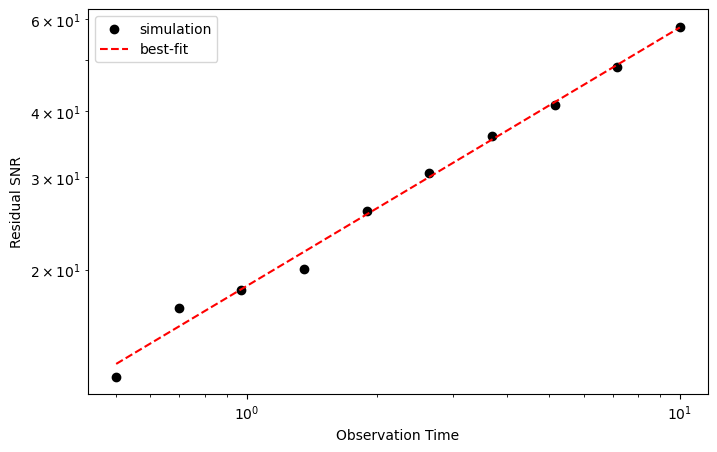

In [15]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
ax.set_xscale('log'), ax.set_yscale('log')

Tobsvals = np.logspace(np.log10(df['Tobs'].min()), np.log10(df['Tobs'].max()))

ax.scatter(Xdata, Ydata, label='simulation', color='k')
ax.plot(Tobsvals, SNRfunc(Tobsvals, *popt), label='best-fit', color='r', linestyle='--')

ax.set_xlabel('Observation Time'), ax.set_ylabel('Residual SNR')
ax.legend()
plt.show()

# Equation 6 power law relationship

Run the `lisasim_snr.py` script to generate the data for this power law test.

In [16]:
data = np.loadtxt("../LISAsim_data_files/snrdiff.txt")

# The exoplanet distance and observation time used in the simulation
D      = 150  # units: pc
Tobs   = 10   # units: year

# Calculate modulation index values
ep = epsilon(data[:,1], inc, 1/data[:,0], fgw0, Msys)

# Convert units
data[:,0] = data[:,0]*u.s.to(u.year)
data[:,1] = data[:,1]*u.kg.to(const.M_jup)

df = pd.DataFrame(data    = np.hstack((data,ep[:,np.newaxis])),
                  columns = ['P', 'M', 'SNRres', 'ep'],
                  )
df

,P,M,SNRres,ep
0,0.002738,0.100000,0.075763,0.000029
1,0.002738,0.125128,0.094798,0.000037
2,0.002738,0.156569,0.118615,0.000046
3,0.002738,0.195911,0.148414,0.000057
4,0.002738,0.245139,0.185698,0.000072
...,...,...,...,...
1439,10.000000,163.172926,6176.575713,9.856429
1440,10.000000,204.174299,5799.756163,11.952853
1441,10.000000,255.478317,4916.909148,14.409844
1442,10.000000,319.673782,5058.855944,17.257540


In [17]:
df_condition = df[df.SNRres < 1000]

print("Max epsilon under condition =", df_condition['ep'].max())

df_condition = df_condition.to_numpy()

print("Number of data points that satisfy the condition: ", df_condition.shape[0])

Max epsilon under condition = 0.3911704745538787
Number of data points that satisfy the condition:  1155


In [18]:
# -------------------------------------------------------
# LISA Sensitivity (Michelson TDI X 2.0) functions
# -------------------------------------------------------

def S_OMS(freqs):
    Aoms = 12e-12
    return (Aoms * 2*np.pi*freqs/const.c.value)**2 * (1 + (2e-3/freqs)**4)

def S_acc(freqs):
    Aacc = 2.4e-15
    return (Aacc / (2*np.pi*freqs*const.c.value))**2 * (1 + (0.4e-3/freqs)**2) * (1 + (freqs/8e-3)**4)

def S_X20_EQarm(freqs, L):
    omega = 2*np.pi*freqs
    Soms = S_OMS(freqs)
    Sacc = S_acc(freqs)
    return 64 * np.sin(2*omega*L/const.c.value)**2 * np.sin(omega*L/const.c.value)**2 * ( Soms + (3+np.cos(2*omega*L/const.c.value))*Sacc )

# LISA arm-length
Larm = 2.5e9

Let's test the following power law functional form:

$
\text{SNR} = a \left(\frac{P}{\text{1 year}}\right)^b \left(\frac{M}{\text{M}_\text{Jup}}\right)^c \Big(\frac{\text{M}_\odot}{\text{M}_\text{sys} + M}\Big)^d \Bigg[ \sin(i) \left(\frac{\mathcal{M}}{0.5 \text{ M}_\odot}\right)^{5/3} \left(\frac{\text{150}}{D}\right) \left(\frac{T_\text{obs}}{\text{4 years}}\right)^{1/2} \left(\frac{f_\text{GW,0}}{\text{1 mHz}}\right)^{5/3} \left(\frac{S^{(1)}_N\left(f_\text{GW,0}\right)}{S^{(1)}_N\left(\text{1 mHz}\right)}\right)^{-1/2} \Bigg]
$

**NOTE**:  From the previous two tests, we know there exists a power law dependence on the GW source distance $D$ and the observation time $T_\text{obs}$.  In this specific test, we are holding those and the rest of the terms in the square brackets of this expression constant.  But we include their values in the fit in order to recover the best-fit value of the $a$ parameter for this specific system.

We will check both a "linear" and "log" fit of this equation to the data.

In [19]:
def SNRfunc(X, a, b, c, d):
    P, M = X
    fixed_terms = np.sin(inc) * (Mchirp/0.5)**(5/3) * (150/D) * (Tobs/4)**(1/2) * (fgw0/1e-3)**(5/3) * (S_X20_EQarm(fgw0,Larm)/S_X20_EQarm(1e-3,Larm))**(-1/2)
    return a * (P/1)**b * (M/1)**c * (1 / ((Msys*u.kg.to(u.Msun)) + (M*u.Mjup.to(u.Msun))))**d * fixed_terms
    
Xdata = df_condition[:,[0,1]].T
Ydata = df_condition[:,2]

popt, pcov = curve_fit(SNRfunc, Xdata, Ydata)#, p0=[1,3/2,-3/2,-1])

print("Best fit values (linear-fit): ", popt)

Best fit values (linear-fit):  [29.26421791  0.66434741  0.99714182  0.66356968]


In [20]:
def log10SNRfunc(X, a, b, c, d):
    P, M = X
    fixed_terms = np.sin(inc) * (Mchirp/0.5)**(5/3) * (150/D) * (Tobs/4)**(1/2) * (fgw0/1e-3)**(5/3) * (S_X20_EQarm(fgw0,Larm)/S_X20_EQarm(1e-3,Larm))**(-1/2)
    return np.log10(a) + b*np.log10(P/1) + c*np.log10(M/1) + d*np.log10(1 / ((Msys*u.kg.to(u.Msun)) + (M*u.Mjup.to(u.Msun)))) + np.log10(fixed_terms)
    
Xdata = df_condition[:,[0,1]].T
Ydata = df_condition[:,2]

popt, pcov = curve_fit(log10SNRfunc, Xdata, np.log10(Ydata))#, p0=[20, 2/3, 1, 2/3])

print("Best fit values (log-fit): ", popt)

Best fit values (log-fit):  [29.04490834  0.66625233  0.99985701  0.66877334]
